In [63]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [45]:
df = yf.download("GOOG")

/tmp/ipython-input-4082361223.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG")
[*********************100%***********************]  1 of 1 completed


In [46]:
returns = np.log(1+df['Close'].pct_change())

In [48]:
mean, sigma = returns.mean(), returns.std()
dt = 1/252

,0
Ticker,
GOOG,0.014411


In [49]:
mean_hat, sigma_hat = mean/dt + (0.5*sigma**2)/dt, sigma/np.sqrt(dt)

In [53]:
randm = np.random.normal(mean_hat,sigma_hat)

array([0.0837429])

In [51]:
Z0 = df["Open"].iloc[-1]

In [56]:
sim_price = Z0 * (randm+1).cumprod()

,2025-12-30
Ticker,
GOOG,416.460041


In [70]:
S = np.zeros((252 + 1, 1000))
S[0] = Z0.iloc[0]

for t in range(1, 252 + 1):
    Z = np.random.normal(mean, sigma, 1000)
    S[t] = S[t - 1] * np.exp(
        (mean.iloc[0] - 0.5 * sigma.iloc[0]**2) * dt +
        sigma.iloc[0] * np.sqrt(dt) * Z
    )

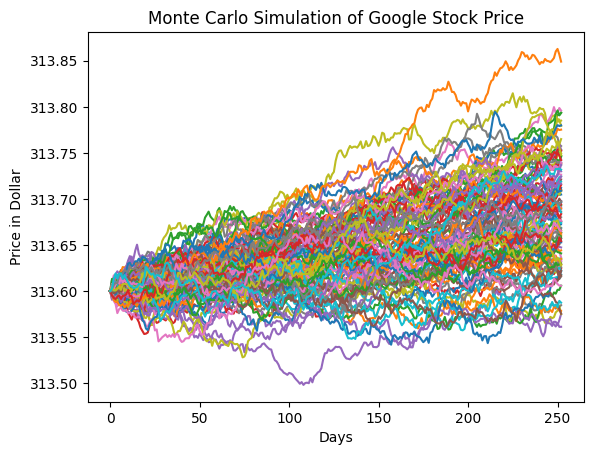

In [77]:
import matplotlib.pyplot as plt

plt.plot(S[:, :100])  # plot 50 sample paths
plt.title("Monte Carlo Simulation of Google Stock Price")
plt.xlabel("Days")
plt.ylabel("Price in Dollar")
plt.show()